## Colab Runtime Setup
Before running the rest of the notebook:
1. Go to **Runtime > Change runtime type** and select a **GPU** (T4 is fine).
2. Run the setup cells below to confirm the GPU is attached and clone/pull the latest `ECE1508` repo into local (ephemeral) storage.

Note: `drive.mount()` doesn't work when connected via VS Code's Colab integration (it needs the native browser UI to complete Google auth), so this session's outputs live only in `/content` and won't survive a runtime restart. Workflow: edit locally → commit + push → re-run the clone/pull cell here → reopen the notebook tab if it was already open → run the rest.

In [1]:
!nvidia-smi

Fri Aug  7 00:09:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [3]:
import os

REPO_URL = "https://github.com/Stevey8/ECE1508.git"
BRANCH = "main"
repo_dir = "/content/ECE1508"

if not os.path.isdir(repo_dir):
    !git clone -b {BRANCH} {REPO_URL} {repo_dir}
else:
    !cd {repo_dir} && git pull

os.chdir(os.path.join(repo_dir, "a5"))
print(f"Working directory set to: {os.getcwd()}")

Cloning into '/content/ECE1508'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 80 (delta 24), reused 66 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 26.14 MiB | 14.88 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Working directory set to: /content/ECE1508/a5


# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 5: Diffusion Models
## Question 5: DDPM on MNIST Digit 8

In this question, we train a tiny __DDPM__ to generate digit 8 from MNIST.

### Loading Modules

In [4]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from tqdm import tqdm


# Device
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print('Using device:', device)

Using device: cuda


### DDPM Setup

In DDPM, we first choose a $\beta$-schedule, and then derive the other quantities from it. Recall that

$$
\beta_t \in (0,1)
$$

represents the amount of noise added at step $t$. We consider a linear scheduling between a `beta_start` and `beta_end`. This means the noise level gradually increases from `beta_start` to `beta_end` over `T` timesteps.

Once the $\beta_t$ is defined, we compute

$$
\alpha_t = 1 - \beta_t
$$

which gives the amount of signal that remains after one diffusion step. We also define the cumulative product of $\alpha$ as

$$
\bar{\alpha}_t = \prod*{s=1}^{t} \alpha_s.
$$

This tells us how much of the original image remains after $t$ noising steps. The forward diffusion equation is then given by

$$
x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon
$$

where $\epsilon$ is standard Gaussian noise. The reverse diffusion step uses the posterior which is given by

$$
q(x_{t-1} \mid x_t, x_0)
$$

whose variance is

$$
\tilde{\beta}_t = \beta_t \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}
$$

In the sequel, we set the parameters needed for forward and backward diffusion.

In [5]:
# Process Length
T = 100 
beta_start = 1e-4
beta_end = 2e-2

# Set Beta linearly increasing
betas = torch.linspace(beta_start, beta_end, T, device=device)

# Compute alpha = 1 - beta
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Compute all parameters
sqrt_alphas = torch.sqrt(alphas)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

# Let's define the extract function
def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(-1, 1, 1, 1).expand(x_shape)

We also use the same sinusoidal time embedding as the one in Question 2

In [6]:
def sinusoidal_embedding(t, dim=32):
    half_dim = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half_dim, device=t.device).float() / (half_dim - 1)
    )
    args = t.float().view(-1,1) * freqs.view(1,-1)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

### Denoising Network

We now implement a simple ResNet for denoising. This is not going to work very sophisticated, but it can still do the job to some basic extent. In this model, the residual block is considered as follows:

Let $x$ be the input map, and $\texttt{emb}$ be the time embedding. Then, the block computes

$$
h \gets \mathrm{Conv}\Big(\mathrm{SiLU}(\mathrm{GN}(x))\Big)
$$
with a  a $3 \times 3$ filter, where $(\mathrm{GN})$ is Group Normalization. It then incorporate time embedding as
$$
h \gets h + W_t \texttt{emb}
$$
for some linear layer $W_t$. We then pass another $3\times 3$ convolution and compute
$$
h \gets \mathrm{Conv} \Big(\mathrm{SiLU}(\mathrm{GN}(h))\Big).
$$
The output is then given as
$$
y = h + \mathrm{Skip}(x)
$$
where $\mathrm{Skip}(x)$ is
* either identity if input and output dimensions match
* or a $1\times 1$ convolution if they do not match. 

In [7]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_ch=64):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_ch, out_ch)

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.act = nn.SiLU()
        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x, temb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.time_proj(self.act(temb)).view(temb.shape[0], -1, 1, 1)
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)

We now implement the Denoiser Model as follows

1. **Time Embedding**  
   timestep $t$ is converted into a sinusoidal embedding, then passed through an MLP to get a 64-dim time vector.

2. **Input Preparation**  
   the input image $x$ is first mapped to 32 channels by a $3 \times 3$ convolution.

3. **Residual Processing**  
   three ResBlocks process the feature map as
   $$
   32 \rightarrow 32 \rightarrow 64 \rightarrow 64
   $$
   and __each block receives the time embedding.__

4. **Output Head**  
   Output head applies
   
   GroupNorm + SiLU + final $3 \times 3$ convolution 
   
   to map the features back to one output channel.


In [8]:
class Denoiser(nn.Module):
    def __init__(self, time_dim=32):
        super().__init__()
        self.time_dim = time_dim

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
        )

        ## COMPLETE ##
        self.in_conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.block1 = ResBlock(32, 32, time_ch=64)
        self.block2 = ResBlock(32, 64, time_ch=64)
        self.block3 = ResBlock(64, 64, time_ch=64)

        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        self.act = nn.SiLU()

    def forward(self, x, t):
        # t: integer timestep tensor in [0, T-1]
        ## COMPLETE ##
        temb = self.time_mlp(sinusoidal_embedding(t, self.time_dim))
        h = self.in_conv(x)
        h = self.block1(h, temb)
        h = self.block2(h, temb)
        h = self.block3(h, temb)
        return self.out_conv(self.act(self.out_norm(h)))

### Forward Diffusion and Loss

For each minibatch we sample a random time step, corrupt the clean image, and train
the network to predict the added noise.

In [9]:
# Let us implement the time sampling and image corruption
def q_sample(x0, t, noise=None):
    ## COMPLETE ##
    if noise is None: 
        noise = torch.randn_like(x0)
    sqrt_ab = extract(sqrt_alpha_bars, t, x0.shape)
    sqrt_one_minus_ab = extract(sqrt_one_minus_alpha_bars, t, x0.shape)
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise


## Define the loss between the model noise prediction and true noise
def ddpm_loss(model, x0):
    ## COMPLETE ##
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    noise_pred = model(x_t, t)
    return F.mse_loss(noise_pred, noise)

### Reverse Diffusion

Finally, we implement the time trajectory that starts from pure Gaussian noise and iteratively denoises for `T` steps.

At a single time step 

$$
x_{t−1} = \mu_{\theta} (x,t) + \sqrt{\tilde{\beta}_t} z
$$

with $z \sim N(0,1)$, except at the final step $t=0$, where $z$ is skipped.

In [10]:
# Sample in a single time
@torch.no_grad()
def p_sample(model, x, t):
   ## COMPLETE ##
   B = x.shape[0]
   t_batch = torch.full((B,), t, device=x.device, dtype=torch.long)

   noise_pred = model(x, t_batch)

   sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t_batch, x.shape)
   beta_t = extract(betas, t_batch, x.shape)
   sqrt_one_minus_ab_t = extract(sqrt_one_minus_alpha_bars, t_batch, x.shape)

   mean = sqrt_recip_alpha_t * (x - beta_t / sqrt_one_minus_ab_t * noise_pred)

   if t > 0: 
      var = extract(posterior_variance, t_batch, x.shape)
      return mean + torch.sqrt(var) * torch.randn_like(x)
   return mean


# Go back in time
@torch.no_grad()
def sample_ddpm(model, shape):
   ## COMPLETE ##
   model.eval()
   x = torch.randn(shape, device=device)
   for t in reversed(range(T)):
      x = p_sample(model, x, t)
   return x


# Show the output
def show_images(x, nrow=4, title=None):
    x = x.detach().cpu().clamp(-1, 1)
    x = (x + 1) / 2
    grid = make_grid(x, nrow=nrow)
    plt.figure(figsize=(5, 5))
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.show()

### Data

We keep working with digit `8`. You can increase the subset size later if you want slightly better samples.

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

full_train = MNIST(root='data', train=True, download=True, transform=transform)
indices_8 = [i for i, (_, y) in enumerate(full_train) if y == 8]
subset_size = min(3000, len(indices_8))
train_indices = indices_8[:subset_size]
train_set = Subset(full_train, train_indices)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]


### Training
We now write the training loop.

In [12]:
model = Denoiser(time_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for x, _ in pbar:
        x = x.to(device)
        optimizer.zero_grad()
        loss = ddpm_loss(model, x)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)

    print(f'Epoch {epoch+1}: loss = {avg_loss:.4f}')

Epoch 1/100: 100%|██████████| 24/24 [00:01<00:00, 13.98it/s, loss=0.3137]


Epoch 1: loss = 0.5190


Epoch 2/100: 100%|██████████| 24/24 [00:00<00:00, 57.34it/s, loss=0.2665]


Epoch 2: loss = 0.3121


Epoch 3/100: 100%|██████████| 24/24 [00:00<00:00, 55.64it/s, loss=0.2965]


...

Epoch 98: loss = 0.0826


Epoch 99/100: 100%|██████████| 24/24 [00:00<00:00, 55.07it/s, loss=0.0714]


Epoch 99: loss = 0.0808


Epoch 100/100: 100%|██████████| 24/24 [00:00<00:00, 58.32it/s, loss=0.0735]

Epoch 100: loss = 0.0833


### Sampling
Let us now sample the model and look at the outputs images. 

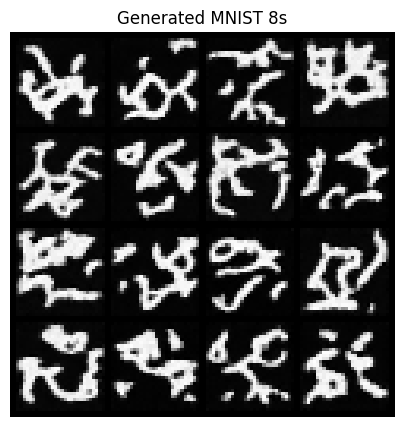

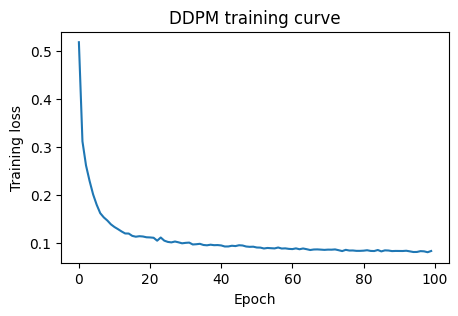

In [13]:
samples = sample_ddpm(model, (16, 1, 28, 28))
show_images(samples, nrow=4, title='Generated MNIST 8s')

# Plot also the training curve
plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('DDPM training curve')
plt.show()

### Question: _Track the samples over time and explain your observation._

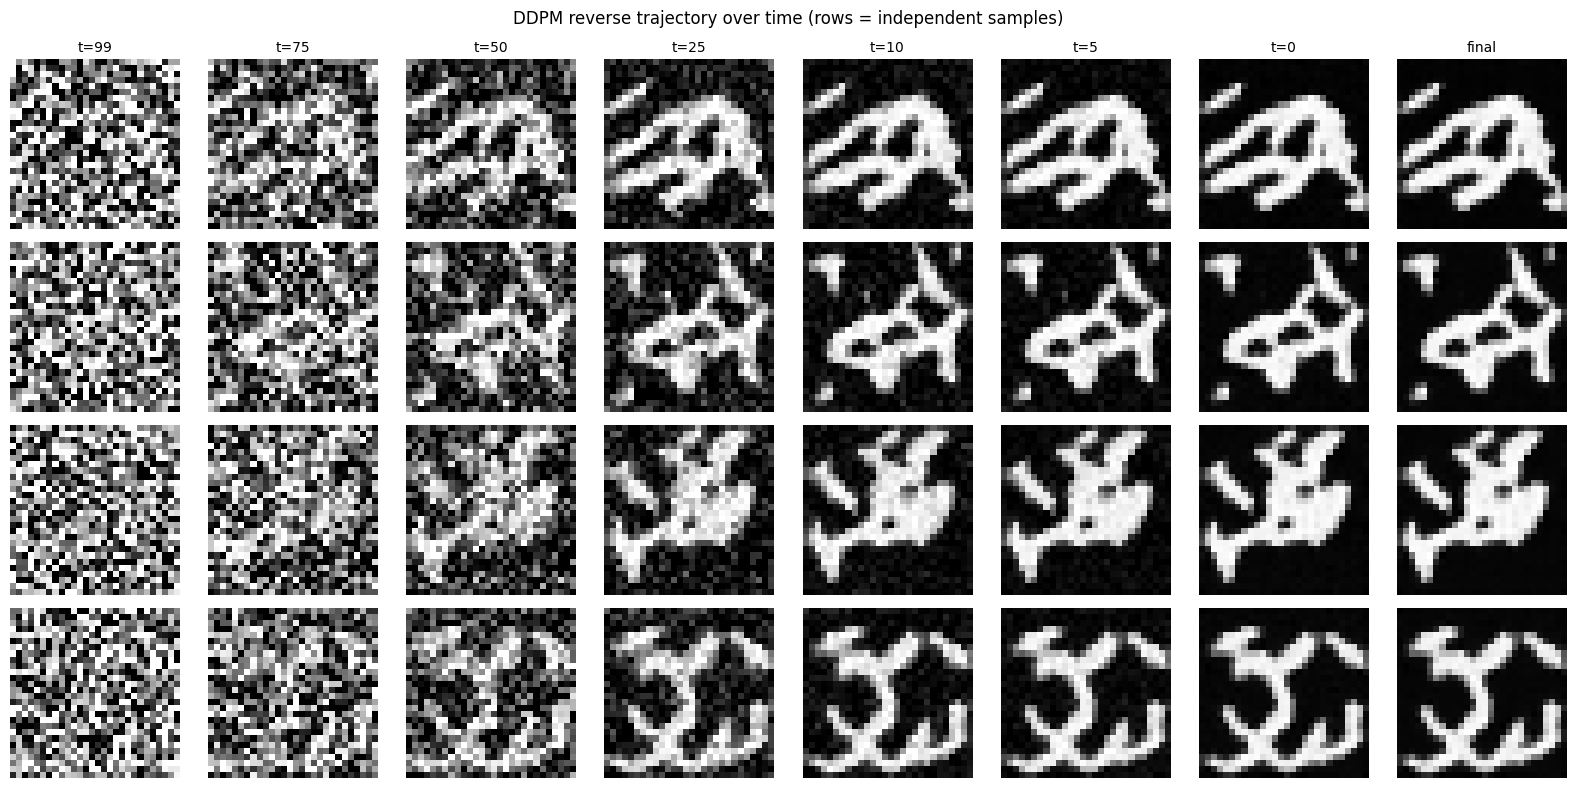

In [16]:
@torch.no_grad()
def sample_ddpm_track(model, shape, snapshot_ts=None):
    model.eval()
    if snapshot_ts is None:
        snapshot_ts = [99, 75, 50, 25, 10, 5, 0]

    x = torch.randn(shape, device=device)
    snapshots = {}

    for t in reversed(range(T)):
        if t in snapshot_ts:
            snapshots[t] = x.clone()  # x_t, before this step's denoising update
        x = p_sample(model, x, t)

    snapshots[-1] = x.clone()  # final x_0, after the last denoising step
    return snapshots


assert 'model' in globals(), "No trained model in memory — rerun the training cell first (no checkpoint was saved for Q3)."

snapshot_ts = [99, 75, 50, 25, 10, 5, 0]
n_samples = 4

snapshots = sample_ddpm_track(model, (n_samples, 1, 28, 28), snapshot_ts=snapshot_ts)
ordered_ts = sorted(snapshots.keys(), reverse=True)  # e.g. 99, 75, ..., 0, -1(final)

fig, axes = plt.subplots(n_samples, len(ordered_ts), figsize=(2 * len(ordered_ts), 2 * n_samples))
for col, t in enumerate(ordered_ts):
    imgs = snapshots[t].detach().cpu().clamp(-1, 1)
    imgs = (imgs + 1) / 2
    for row in range(n_samples):
        ax = axes[row, col]
        ax.imshow(imgs[row, 0], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title('final' if t == -1 else f't={t}', fontsize=10)

plt.suptitle('DDPM reverse trajectory over time (rows = independent samples)')
plt.tight_layout()
plt.show()

Over time samples were reversed from complete noise back to having some strucutre. Although it looks nowhere like a figure 8 shape, the diffusion process and the reversal can still be seen. 

### Question: _Compared to VAE and GAN, do you think that it was a good idea to use DDPM for this simple task? Explain your answer._
It does not look like DDPM was ideal for this task. The generated samples look a little too complicated instead of just a clean figure 8 shape. On the other hand, a GAN or VAE with relatively simple architecture would typically produce recognizable (if blurry, for VAE) MNIST digits without the multi-step sampling overhead. 